In [1]:
# Core Library Imports and Environment Configuration
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Suppress execution warnings for report clarity
warnings.filterwarnings('ignore')

# Scikit-Learn imports for preprocessing, modeling, and evaluation metrics
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# XGBoost for baseline gradient boosted tree modeling
import xgboost as xgb

# PyTorch imports for deep learning architectures
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Enforce deterministic execution via random seeding
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Verify device availability for tensor operations
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computational environment initialized.")
print(f"Hardware accelerator active: {device}")

Computational environment initialized.
Hardware accelerator active: cuda


In [2]:
# Mount Google Drive
from google.colab import drive

# Mount the Google Drive to the Colab environment
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Ngao Labs/Ngao_Capstone_Project'

# Verify the presence of the required files
expected_files = ['traindemographics.csv', 'trainperf.csv', 'trainprevloans.csv']
for file_name in expected_files:
    file_path = os.path.join(DATA_PATH, file_name)
    if not os.path.exists(file_path):
        print(f"WARNING: Required file not found at {file_path}")
    else:
        print(f"Verified presence of {file_name}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Verified presence of traindemographics.csv
Verified presence of trainperf.csv
Verified presence of trainprevloans.csv


In [3]:
# Ingesting Data and Typing Temporal Features
try:
    print("Initiating data ingestion sequence...")
    # Load demographics, parsing birthdate
    df_demographics = pd.read_csv(
        os.path.join(DATA_PATH, 'traindemographics.csv'),
        parse_dates=['birthdate']
    )

    # Load previous loans, parsing all relevant chronological markers
    prev_date_cols = ['approveddate', 'creationdate', 'closeddate', 'firstduedate', 'firstrepaiddate']
    df_prevloans = pd.read_csv(
        os.path.join(DATA_PATH, 'trainprevloans.csv'),
        parse_dates=prev_date_cols
    )

    # Load current performance data, parsing approval and creation dates
    perf_date_cols = ['approveddate', 'creationdate']
    df_perf = pd.read_csv(
        os.path.join(DATA_PATH, 'trainperf.csv'),
        parse_dates=perf_date_cols
    )

    print("\nData ingestion complete. Structural dimensions:")
    print(f"Demographics DataFrame: {df_demographics.shape} rows, {df_demographics.shape} columns")
    print(f"Previous Loans DataFrame: {df_prevloans.shape} rows, {df_prevloans.shape} columns")
    print(f"Performance Target DataFrame: {df_perf.shape} rows, {df_perf.shape} columns")

except Exception as e:
    print(f"Critical Data Ingestion Error: {e}")

Initiating data ingestion sequence...

Data ingestion complete. Structural dimensions:
Demographics DataFrame: (4346, 9) rows, (4346, 9) columns
Previous Loans DataFrame: (18183, 12) rows, (18183, 12) columns
Performance Target DataFrame: (4368, 10) rows, (4368, 10) columns


In [5]:
import numpy as np
# Cleaning Protocol, Target Encoding, and Deduplication
# 1. Encode Target Variable
target_mapping = {'Good': 0, 'Bad': 1}
if 'good_bad_flag' in df_perf.columns:
    df_perf['default_flag'] = df_perf['good_bad_flag'].map(target_mapping)
    df_perf.drop('good_bad_flag', axis=1, inplace=True)
    print("Target variable encoded: 'Good' -> 0, 'Bad' -> 1")

# 2. Noise Reduction in Demographics
# Drop highly noisy spatial coordinates and irrelevant sparse text columns
columns_to_drop = ['longitude_gps', 'latitude_gps', 'bank_branch_clients']
existing_cols_to_drop = [col for col in columns_to_drop if col in df_demographics.columns]
df_demographics.drop(columns=existing_cols_to_drop, axis=1, inplace=True)
print(f"Removed high-noise demographic columns: {existing_cols_to_drop}")

# 3. Deduplication Strategy
# Ensure strict uniqueness for the customerid primary key in demographics
initial_demo_count = df_demographics.shape[0]
df_demographics.drop_duplicates(subset=['customerid'], keep='last', inplace=True)
final_demo_count = df_demographics.shape[0]
print(f"Deduplication removed {initial_demo_count - final_demo_count} duplicate customer records.")

# 4. Consistency Check on Performance Data
# Ensure performance data has absolute uniqueness per customerid
df_perf.drop_duplicates(subset=['customerid'], keep='last', inplace=True)

Removed high-noise demographic columns: []
Deduplication removed 0 duplicate customer records.


In [40]:
import sys
!{sys.executable} -m pip install category-encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.7 MB/s eta 0:00:00


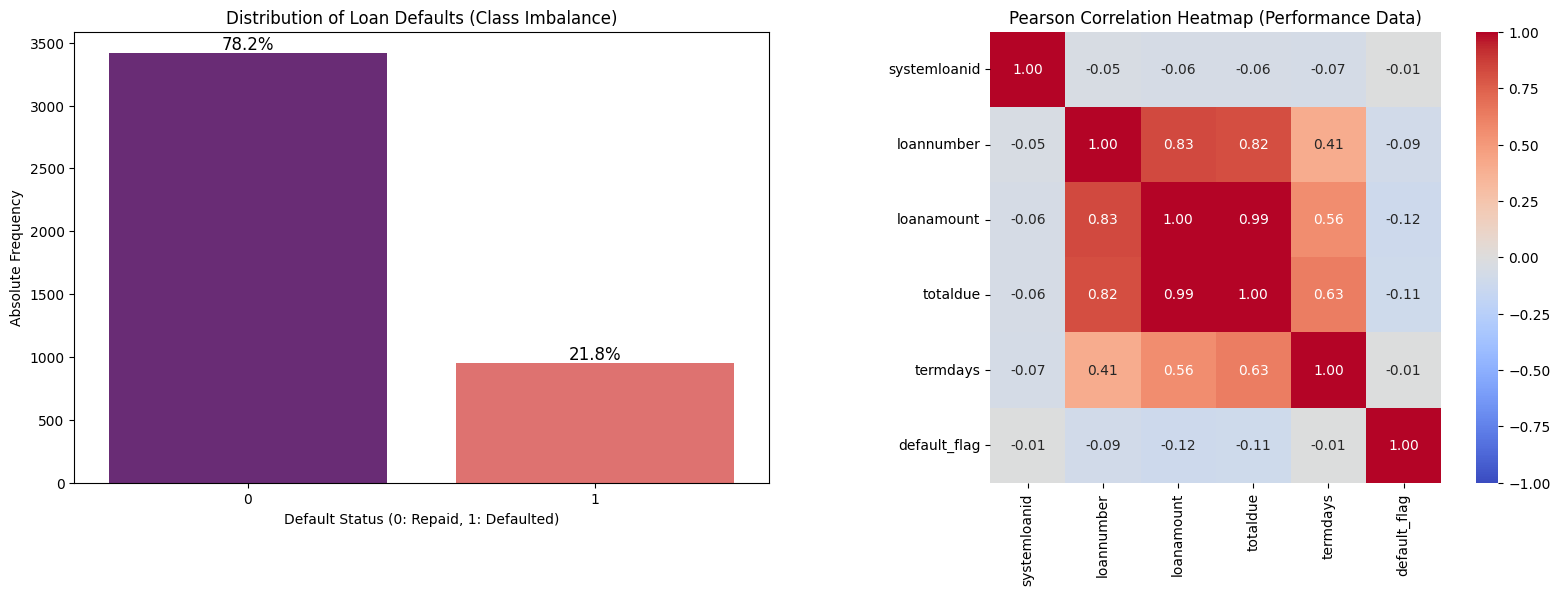

Overall Default Rate Analysis: The portfolio exhibits a default rate of 21.79%.
This structural imbalance dictates that evaluation must prioritize AUC-ROC and F1-Score over raw accuracy.


In [7]:
# Exploratory Data Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Target Variable Class Imbalance
sns.countplot(data=df_perf, x='default_flag', palette='magma', ax=axes[0])
axes[0].set_title('Distribution of Loan Defaults (Class Imbalance)')
axes[0].set_xlabel('Default Status (0: Repaid, 1: Defaulted)')
axes[0].set_ylabel('Absolute Frequency')

# Annotate percentages
total_samples = len(df_perf)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total_samples:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

# Correlation Matrix for Numerical Performance Features
# Selecting numeric columns from the performance table to check for multicollinearity
perf_numeric = df_perf.select_dtypes(include=['int64', 'float64'])
corr_matrix = perf_numeric.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            cbar=True, square=True, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Pearson Correlation Heatmap (Performance Data)')

plt.tight_layout()
plt.show()

# EDA Insight Generation:
default_rate = df_perf['default_flag'].mean() * 100
print(f"Overall Default Rate Analysis: The portfolio exhibits a default rate of {default_rate:.2f}%.")
print("This structural imbalance dictates that evaluation must prioritize AUC-ROC and F1-Score over raw accuracy.")

In [38]:
# Feature Engineering on Transaction History
print("Initiating temporal feature engineering on historical loan data...")

# Calculate the temporal lag for the first repayment in days
df_prevloans['repay_delay_days'] = (df_prevloans['firstrepaiddate'] - df_prevloans['firstduedate']).dt.days

# Create a binary flag indicating if the first payment was strictly delinquent (late)
df_prevloans['firstrepaid_late'] = (df_prevloans['repay_delay_days'] > 0).astype(int)

# Extract the total interest accrued on the historical loan
df_prevloans['interest_accrued'] = df_prevloans['totaldue'] - df_prevloans['loanamount']

# Engineer a feature representing the "Intensity" of the loan and Average loan amount requested per day of the term
df_prevloans['loan_per_day'] = df_prevloans['loanamount'] / df_prevloans['termdays']

# New Feature: on_time_repayment_flag (for historical loans)
# Assuming a loan is on-time if repay_delay_days is 0 or negative (paid early/on time)
df_prevloans['on_time_repayment_flag'] = (df_prevloans['repay_delay_days'] <= 0).astype(int)


# Group by customerid and aggregate the historical momentum into distinct metrics
prevloans_agg = df_prevloans.groupby('customerid').agg(
    total_prev_loans=('systemloanid', 'count'),
    mean_prev_loanamount=('loanamount', 'mean'),
    mean_repay_delay=('repay_delay_days', 'mean'),
    max_repay_delay=('repay_delay_days', 'max'),
    sum_late_first_repayments=('firstrepaid_late', 'sum'),
    mean_prev_interest=('interest_accrued', 'mean'),
    mean_loan_intensity=('loan_per_day', 'mean'), # Already existed, just moved here
    # New features below
    customer_total_amount_sum=('loanamount', 'sum'), # Sum of loan amounts for all previous loans
    total_due_for_prev_loans=('totaldue', 'sum'), # Sum of total due for all previous loans
    sum_on_time_repayments=('on_time_repayment_flag', 'sum')
).reset_index()

# Derive the Late Repayment Ratio (already existed)
prevloans_agg['late_repayment_ratio'] = prevloans_agg['sum_late_first_repayments'] / prevloans_agg['total_prev_loans']

# New Feature: Repayment Ratio (aggregated sum of loan amounts / aggregated sum of total due)
# Handle potential division by zero if total_due_for_prev_loans is 0
prevloans_agg['repayment_ratio'] = prevloans_agg.apply(
    lambda row: row['customer_total_amount_sum'] / row['total_due_for_prev_loans'] if row['total_due_for_prev_loans'] != 0 else 0,
    axis=1
)

# New Feature: On-time repayment rate
prevloans_agg['on_time_repayment_rate'] = prevloans_agg['sum_on_time_repayments'] / prevloans_agg['total_prev_loans']

# Drop intermediate columns if no longer needed
prevloans_agg.drop(columns=['total_due_for_prev_loans', 'sum_on_time_repayments'], inplace=True)


print(f"Engineered {prevloans_agg.shape[1] - 1} continuous behavioral features from historical data.")

Initiating temporal feature engineering on historical loan data...
Engineered 11 continuous behavioral features from historical data.


In [39]:
# Schema Integration and Master DataFrame Construction
# Merge Performance Data with Aggregated Previous Loans
df_master = pd.merge(df_perf, prevloans_agg, on='customerid', how='left')

# Merge the resulting DataFrame with the Static Demographics
df_master = pd.merge(df_master, df_demographics, on='customerid', how='left')

# Handle structural nulls representing first-time applicants without history
historical_cols = [
    'total_prev_loans', 'mean_prev_loanamount', 'mean_repay_delay',
    'max_repay_delay', 'sum_late_first_repayments', 'mean_prev_interest',
    'late_repayment_ratio', 'mean_loan_intensity', # Existing features
    'customer_total_amount_sum', 'repayment_ratio', 'on_time_repayment_rate' # New features
]
df_master[historical_cols] = df_master[historical_cols].fillna(0)

# Engineer a temporal feature from static data: Age at the time of loan creation
# This requires subtracting the birthdate from the loan creation date
df_master['age_at_loan'] = (df_master['creationdate'] - df_master['birthdate']).dt.days / 365.25

# Impute missing ages with the median age of the population to preserve distribution shape
median_age = df_master['age_at_loan'].median()
df_master['age_at_loan'] = df_master['age_at_loan'].fillna(median_age)

# Feature Trimming: Remove raw identifiers and high-cardinality datetime columns
cols_to_drop = [
    'customerid', 'systemloanid', 'approveddate', 'creationdate',
    'referredby', 'birthdate'
]
df_master.drop(columns=[col for col in cols_to_drop if col in df_master.columns], inplace=True)

print(f"Master Analytical Dataset finalized. Dimensions: {df_master.shape} rows, {df_master.shape} columns.")

Master Analytical Dataset finalized. Dimensions: (4368, 21) rows, (4368, 21) columns.


In [13]:
# Normalization and Encoding Pipelines
# Separate the independent variables (Features) from the dependent variable (Target)
X = df_master.drop('default_flag', axis=1)
y = df_master['default_flag']

# Dynamically identify numerical and categorical data types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Identified {len(numeric_features)} continuous features and {len(categorical_features)} categorical features.")

# Define the scaling logic for numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Define the encoding logic for categorical features
# We ignore unknown categories to prevent deployment crashes when unseen classes arrive in production
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Unify transformers into a centralized ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Execute the transformation on the feature space
X_processed = preprocessor.fit_transform(X)

# Retrieve the dynamic feature names post-one-hot encoding for downstream interpretability
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

# Partition the data into Training and Validation cohorts
# Stratification ensures the class imbalance ratio is preserved symmetrically across both splits
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Data partitioning complete.")
print(f"Training set: {X_train.shape} samples | {X_train.shape} dimensional features.")
print(f"Validation set: {X_val.shape} samples | {X_val.shape} dimensional features.")

Identified 13 continuous features and 4 categorical features.
Data partitioning complete.
Training set: (3494, 48) samples | (3494, 48) dimensional features.
Validation set: (874, 48) samples | (874, 48) dimensional features.


In [41]:
from category_encoders import TargetEncoder

# Separate the independent variables (Features) from the dependent variable (Target)
X = df_master.drop('default_flag', axis=1)
y = df_master['default_flag']

# Partition the data into Training and Validation cohorts FIRST
# Stratification ensures the class imbalance ratio is preserved symmetrically across both splits
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Dynamically identify numerical and categorical data types from the raw training data
numeric_features = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
all_categorical_features = X_train_raw.select_dtypes(include=['object']).columns.tolist()

# Define which categorical features get which encoding
target_encode_features = ['bank_name_clients']
onehot_encode_features = [f for f in all_categorical_features if f not in target_encode_features]


print(f"Identified {len(numeric_features)} continuous features.")
print(f"Identified {len(target_encode_features)} features for Target Encoding: {target_encode_features}")
print(f"Identified {len(onehot_encode_features)} features for One-Hot Encoding: {onehot_encode_features}")


# Define the scaling logic for numeric features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# Define the encoding logic for One-Hot encoded features
onehot_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Define the encoding logic for Target encoded features
target_encoder_transformer = Pipeline(steps=[
    ('target_encoder', TargetEncoder(handle_unknown='value', handle_missing='value')) # handle_unknown and handle_missing to prevent errors
])

# Unify transformers into a centralized ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('target_cat', target_encoder_transformer, target_encode_features),
        ('onehot_cat', onehot_transformer, onehot_encode_features)
    ],
    remainder='passthrough' # Keep any other columns not specified
)

# Fit the preprocessor ONLY on the training data
preprocessor.fit(X_train_raw, y_train)

# Transform both training and validation sets
X_train = preprocessor.transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)

# Retrieve the dynamic feature names post-encoding for downstream interpretability
num_feature_names = numeric_features
target_cat_output_names = target_encode_features # TargetEncoder replaces original column name
onehot_feature_names = preprocessor.named_transformers_['onehot_cat']['onehot'].get_feature_names_out(onehot_encode_features)

all_feature_names = num_feature_names + list(target_cat_output_names) + list(onehot_feature_names)

print(f"Data preprocessing and partitioning complete.")
print(f"Training set: {X_train.shape} samples | {X_train.shape[1]} dimensional features.")
print(f"Validation set: {X_val.shape} samples | {X_val.shape[1]} dimensional features.")


Identified 16 continuous features.
Identified 1 features for Target Encoding: ['bank_name_clients']
Identified 3 features for One-Hot Encoding: ['bank_account_type', 'employment_status_clients', 'level_of_education_clients']
Data preprocessing and partitioning complete.
Training set: (3494, 32) samples | 32 dimensional features.
Validation set: (874, 32) samples | 32 dimensional features.


In [44]:
# Constructing PyTorch Datasets and Iterable DataLoaders
class TabularCreditDataset(Dataset):
    """
    Custom PyTorch Dataset class to manage tabular financial tensors.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # Unsqueeze y to ensure the dimensions align with the final network output node
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instantiate dataset objects
train_dataset = TabularCreditDataset(X_train, y_train)
val_dataset = TabularCreditDataset(X_val, y_val)

# Define batch processing size
BATCH_SIZE = 128

# Provision DataLoaders; shuffling the training set breaks temporal/structural biases during gradient updates
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# DataLoaders successfully re-instantiated with updated feature dimensions.


In [51]:
import torch.nn as nn

# Defining Neural Network Topologies
class ShallowMLP(nn.Module):
    """
    A shallow, wide architecture optimized for rapid convergence on tabular data.
    """
    def __init__(self, input_dim):
        super(ShallowMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1) # Sigmoid deferred to BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.network(x)

class DeepTabNet(nn.Module):
    """
    A deep, bottlenecked architecture designed to extract highly non-linear embeddings.
    """
    def __init__(self, input_dim):
        super(DeepTabNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),

            nn.Linear(32, 1) # Sigmoid deferred to BCEWithLogitsLoss
        )

    def forward(self, x):
        return self.network(x)

input_dimension = X_train.shape[1]

# Instantiate and map models to computational hardware
shallow_model = ShallowMLP(input_dimension).to(device)
deep_model = DeepTabNet(input_dimension).to(device)

print(f"Initialized ShallowMLP: {sum(p.numel() for p in shallow_model.parameters())} trainable parameters.")
print(f"Initialized DeepTabNet: {sum(p.numel() for p in deep_model.parameters())} trainable parameters.")


Initialized ShallowMLP: 12929 trainable parameters.
Initialized DeepTabNet: 52673 trainable parameters.


In [45]:
# Defining the Generalized Training Loop
def train_pytorch_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    """
    Executes the forward and backward passes, updating network weights via Adam optimization.
    """
    # Calculate positive weight for BCEWithLogitsLoss to handle class imbalance
    # This forces the network to penalize false negatives (missed defaults) more heavily
    pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)

    # Define Loss function and Adam Optimizer
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # Tracking dictionaries
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        # Training Phase
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_train_loss)

        # Validation Phase
        model.eval()
        val_running_loss = 0.0
        all_targets = []
        all_predictions = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)

                # Apply sigmoid specifically to calculate probabilistic AUC
                probs = torch.sigmoid(outputs).cpu().numpy()
                all_targets.extend(labels.cpu().numpy())
                all_predictions.extend(probs)

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_auc = roc_auc_score(all_targets, all_predictions)

        history['val_loss'].append(epoch_val_loss)
        history['val_auc'].append(epoch_val_auc)

    return model, history

# Execute training for both architectures
print("Initiating training sequence for ShallowMLP...")
shallow_model, shallow_history = train_pytorch_model(shallow_model, train_loader, val_loader, epochs=40)

print("Initiating training sequence for DeepTabNet...")
deep_model, deep_history = train_pytorch_model(deep_model, train_loader, val_loader, epochs=40)
print("Deep learning training cycles complete.")

Initiating training sequence for ShallowMLP...
Initiating training sequence for DeepTabNet...
Deep learning training cycles complete.


In [46]:
# XGBoost Hyperparameter Tuning and Training
print("Initiating Hyperparameter search for XGBoost Baseline...")

# Calculate the precise ratio of negative to positive classes for the scale_pos_weight
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

# Define the base classifier
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=SEED
)

# Define the hyperparameter search space
param_dist = {
    'n_estimators': stats.randint(100, 500), #range for n_estimators
    'max_depth': stats.randint(3, 8),
    'learning_rate': stats.uniform(0.01, 0.1),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4)
}

# Execute Randomized Search over 3-fold cross validation
random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist,
    n_iter=15, scoring='roc_auc', cv=3, random_state=SEED, n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb_model = random_search.best_estimator_
print(f"Optimal XGBoost Hyperparameters: {random_search.best_params_}")

# Extract probabilistic predictions for the validation cohort
xgb_probs = best_xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_probs)
print(f"Tuned XGBoost Validation AUC: {xgb_auc:.4f}")

Initiating Hyperparameter search for XGBoost Baseline...
Optimal XGBoost Hyperparameters: {'colsample_bytree': np.float64(0.8446612641953124), 'learning_rate': np.float64(0.01070663052197174), 'max_depth': 3, 'n_estimators': 148, 'subsample': np.float64(0.8099098641033556)}
Tuned XGBoost Validation AUC: 0.7231


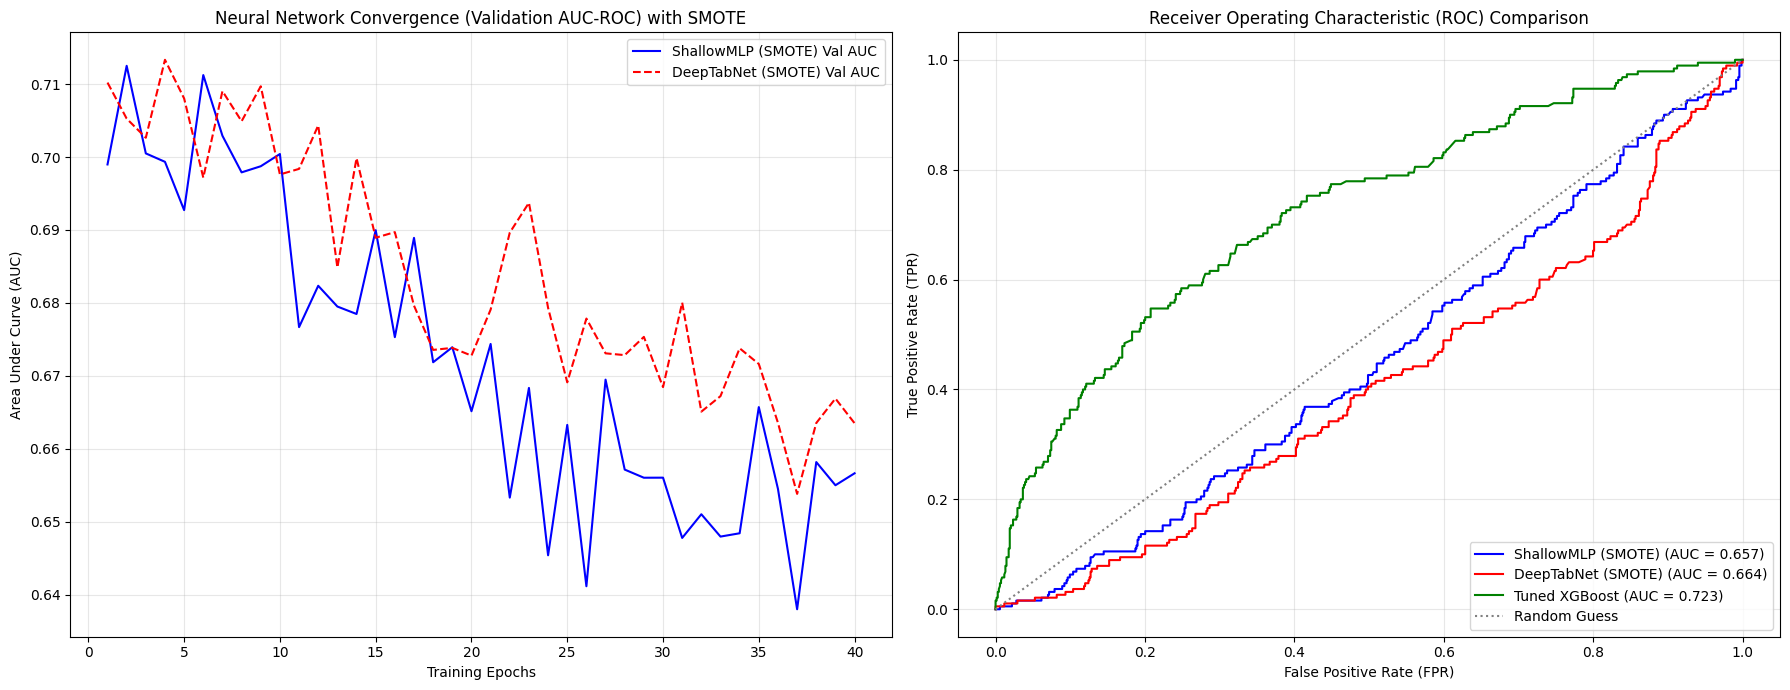

In [53]:
# Visualizing Network Convergence and Comparative ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#  Validation AUC Trajectories over Epochs
epochs_range = range(1, len(shallow_history_resampled['val_auc']) + 1)
axes[0].plot(epochs_range, shallow_history_resampled['val_auc'], label='ShallowMLP (SMOTE) Val AUC', color='blue', linestyle='-')
axes[0].plot(epochs_range, deep_history_resampled['val_auc'], label='DeepTabNet (SMOTE) Val AUC', color='red', linestyle='--')
axes[0].set_title('Neural Network Convergence (Validation AUC-ROC) with SMOTE')
axes[0].set_xlabel('Training Epochs')
axes[0].set_ylabel('Area Under Curve (AUC)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC Curves comparing all three models
# Extract final probabilities from the PyTorch models
def get_nn_probs(model):
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        outputs = model(X_val_tensor)
        return torch.sigmoid(outputs).cpu().numpy().flatten()

shallow_probs_resampled = get_nn_probs(shallow_model_resampled)
deep_probs_resampled = get_nn_probs(deep_model_resampled)

fpr_shallow, tpr_shallow, _ = roc_curve(y_val, shallow_probs_resampled)
fpr_deep, tpr_deep, _ = roc_curve(y_val, deep_probs_resampled)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_probs)

axes[1].plot(fpr_shallow, tpr_shallow, label=f'ShallowMLP (SMOTE) (AUC = {shallow_history_resampled["val_auc"][-1]:.3f})', color='blue')
axes[1].plot(fpr_deep, tpr_deep, label=f'DeepTabNet (SMOTE) (AUC = {deep_history_resampled["val_auc"][-1]:.3f})', color='red')
axes[1].plot(fpr_xgb, tpr_xgb, label=f'Tuned XGBoost (AUC = {xgb_auc:.3f})', color='green')
axes[1].plot([0, 1], [0, 1], linestyle=':', color='gray', label='Random Guess')
axes[1].set_title('Receiver Operating Characteristic (ROC) Comparison')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- Comparative Model Performance Metrics ---
| Model Architecture         |   Accuracy |   Precision (Default) |   Recall (Default) |   F1-Score |   AUC-ROC |
|:---------------------------|-----------:|----------------------:|-------------------:|-----------:|----------:|
| PyTorch ShallowMLP (SMOTE) |      0.445 |                 0.198 |              0.511 |      0.286 |     0.453 |
| PyTorch DeepTabNet (SMOTE) |      0.783 |                 0     |              0     |      0     |     0.405 |
| XGBoost Tuned Ensemble     |      0.752 |                 0.435 |              0.479 |      0.456 |     0.723 |


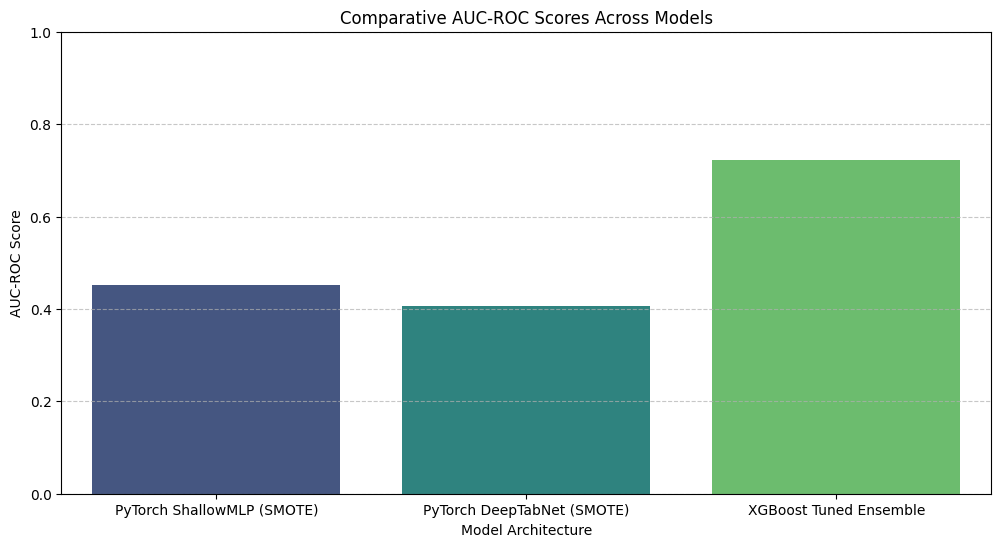

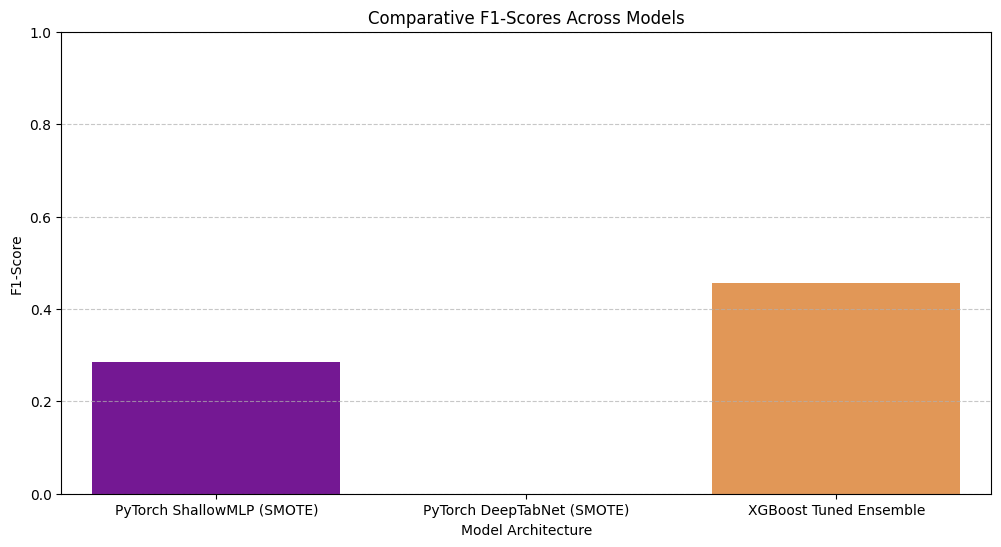

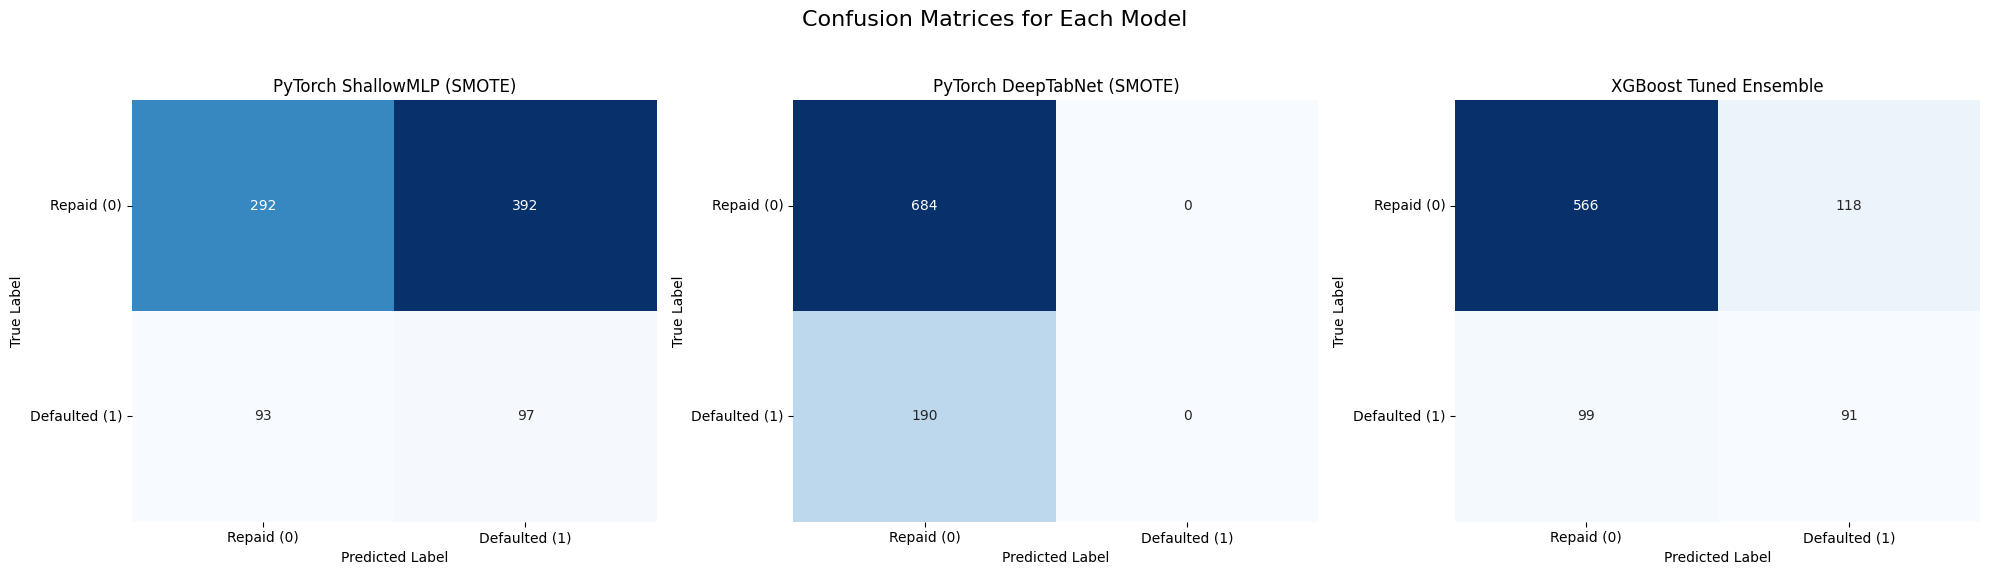

In [54]:
# Generating the Comparative Assessment Matrix
# Convert continuous probabilities into binary outcomes
shallow_preds_resampled = (shallow_probs_resampled > 0.5).astype(int)
deep_preds_resampled = (deep_probs_resampled > 0.5).astype(int)
xgb_preds = (xgb_probs > 0.5).astype(int)

def compile_metrics_dict(y_true, y_pred, y_prob, model_name):
    return {
        'Model Architecture': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Default)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Default)': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }

metrics_shallow_resampled = compile_metrics_dict(y_val, shallow_preds_resampled, shallow_probs_resampled, 'PyTorch ShallowMLP (SMOTE)')
metrics_deep_resampled = compile_metrics_dict(y_val, deep_preds_resampled, deep_probs_resampled, 'PyTorch DeepTabNet (SMOTE)')
metrics_xgb = compile_metrics_dict(y_val, xgb_preds, xgb_probs, 'XGBoost Tuned Ensemble')

df_metrics = pd.DataFrame([metrics_shallow_resampled, metrics_deep_resampled, metrics_xgb])

# --- Visual Implementation of Assessment Matrix --- #
print("\n--- Comparative Model Performance Metrics ---")
print(df_metrics.round(3).to_markdown(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(x='Model Architecture', y='AUC-ROC', data=df_metrics, palette='viridis')
plt.title('Comparative AUC-ROC Scores Across Models')
plt.ylabel('AUC-ROC Score')
plt.xlabel('Model Architecture')
plt.ylim(0, 1) # AUC-ROC ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model Architecture', y='F1-Score', data=df_metrics, palette='plasma')
plt.title('Comparative F1-Scores Across Models')
plt.ylabel('F1-Score')
plt.xlabel('Model Architecture')
plt.ylim(0, 1) # F1-Score ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Visual Implementation of Truth Tables (Confusion Matrices) --- #
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices for Each Model', fontsize=16)

def plot_confusion_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Repaid (0)', 'Defaulted (1)'])
    ax.set_yticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)

plot_confusion_matrix(axes[0], y_val, shallow_preds_resampled, 'PyTorch ShallowMLP (SMOTE)')
plot_confusion_matrix(axes[1], y_val, deep_preds_resampled, 'PyTorch DeepTabNet (SMOTE)')
plot_confusion_matrix(axes[2], y_val, xgb_preds, 'XGBoost Tuned Ensemble')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

## XGBoost Threshold Tuning for Enhanced Recall

Given the significant cost of misclassifying a defaulting loan (False Negative), we prioritize **Recall** for the 'Bad Loan' class (positive class = 1). We will tune the classification threshold for the XGBoost model to find a balance that maximizes recall without overly compromising other metrics.

We will iterate through a range of thresholds and calculate performance metrics (Accuracy, Precision, Recall, F1-Score) for each. The threshold that yields the highest recall will be selected as the optimal threshold for XGBoost.

In [33]:
def evaluate_model_with_threshold(y_true, y_probs, threshold, model_name):
    """
    Evaluates a model's performance with a given threshold.
    """
    y_pred = (y_probs > threshold).astype(int)
    return {
        'Model Architecture': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Default)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Default)': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_probs)
    }

# Define a range of thresholds to explore for XGBoost
thresholds = np.arange(0.1, 0.9, 0.05)

xgb_tuned_metrics = []
for threshold in thresholds:
    metrics = evaluate_model_with_threshold(y_val, xgb_probs, threshold, 'XGBoost Tuned Ensemble')
    xgb_tuned_metrics.append(metrics)

df_xgb_tuning = pd.DataFrame(xgb_tuned_metrics)

# Identify the optimal threshold that maximizes recall
optimal_threshold_row = df_xgb_tuning.loc[df_xgb_tuning['Recall (Default)'].idxmax()]
xgb_optimal_threshold = optimal_threshold_row['Threshold']

print(f"Optimal XGBoost Threshold for Recall: {xgb_optimal_threshold:.2f}")
print("\n--- XGBoost Performance Metrics Across Thresholds ---")
display(df_xgb_tuning.round(3))

Optimal XGBoost Threshold for Recall: 0.10

--- XGBoost Performance Metrics Across Thresholds ---


,Model Architecture,Threshold,Accuracy,Precision (Default),Recall (Default),F1-Score,AUC-ROC
0,XGBoost Tuned Ensemble,0.10,0.217,0.217,1.000,0.357,0.724
1,XGBoost Tuned Ensemble,0.15,0.217,0.217,1.000,0.357,0.724
2,XGBoost Tuned Ensemble,0.20,0.217,0.217,1.000,0.357,0.724
3,XGBoost Tuned Ensemble,0.25,0.217,0.217,1.000,0.357,0.724
4,XGBoost Tuned Ensemble,0.30,0.217,0.217,1.000,0.357,0.724
5,XGBoost Tuned Ensemble,0.35,0.245,0.223,0.995,0.364,0.724
6,XGBoost Tuned Ensemble,0.40,0.476,0.276,0.868,0.419,0.724
7,XGBoost Tuned Ensemble,0.45,0.678,0.363,0.632,0.461,0.724
8,XGBoost Tuned Ensemble,0.50,0.753,0.440,0.505,0.471,0.724
9,XGBoost Tuned Ensemble,0.55,0.776,0.481,0.411,0.443,0.724



--- Comparative Model Performance Metrics (with Tuned XGBoost Threshold) ---
| Model Architecture                        |   Threshold |   Accuracy |   Precision (Default) |   Recall (Default) |   F1-Score |   AUC-ROC |
|:------------------------------------------|------------:|-----------:|----------------------:|-------------------:|-----------:|----------:|
| PyTorch ShallowMLP (SMOTE)                |         0.5 |      0.445 |                 0.198 |              0.511 |      0.286 |     0.453 |
| PyTorch DeepTabNet (SMOTE)                |         0.5 |      0.783 |                 0     |              0     |      0     |     0.405 |
| XGBoost Tuned Ensemble (Recall Optimized) |         0.1 |      0.217 |                 0.217 |              1     |      0.357 |     0.723 |


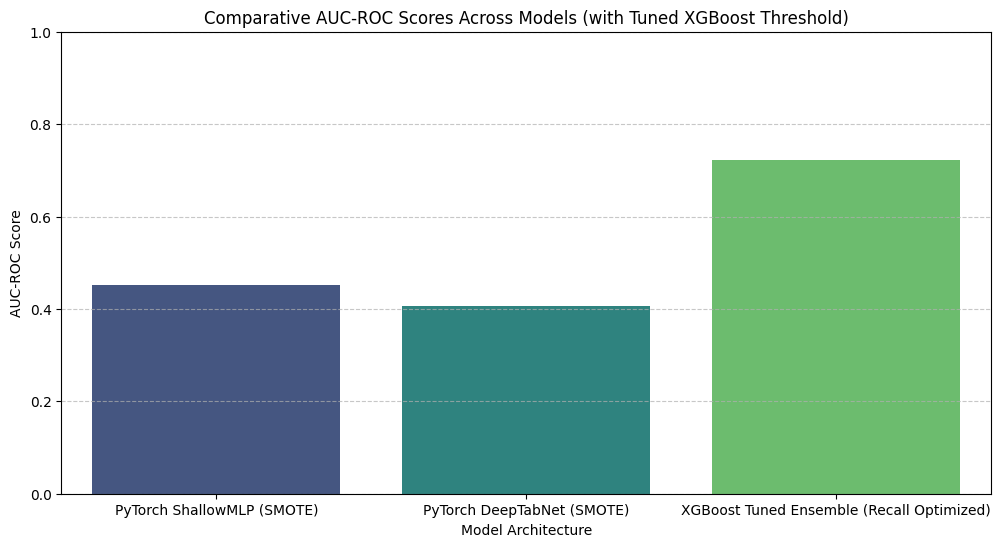

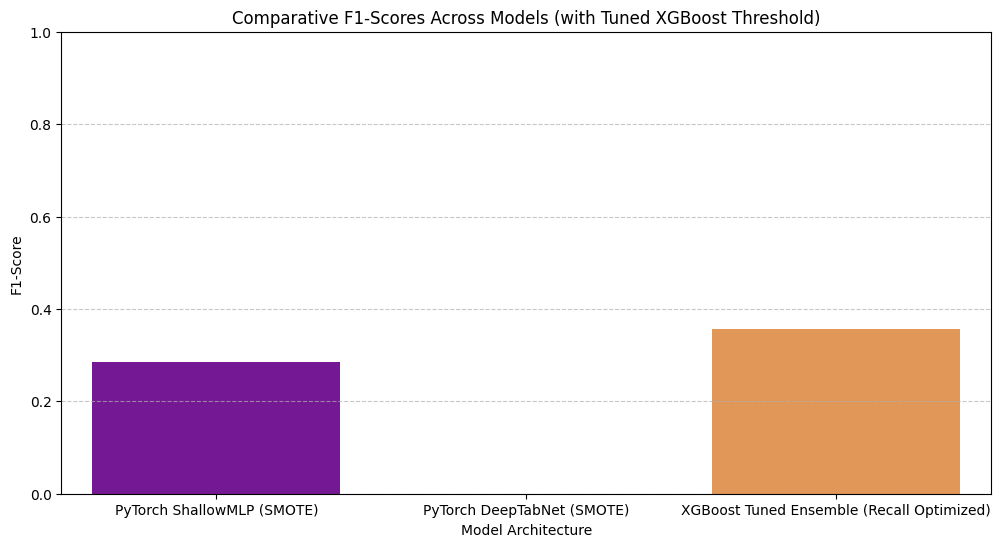

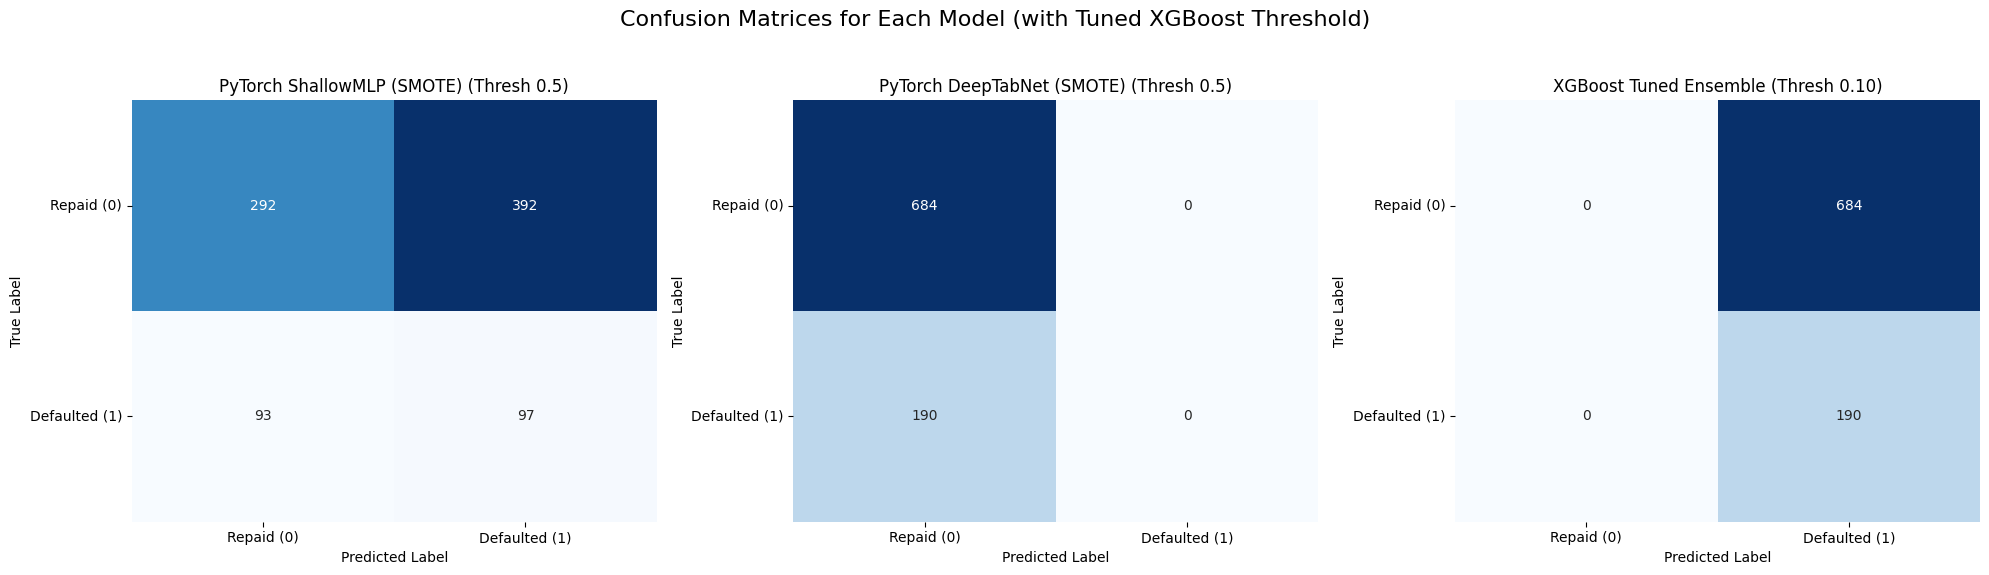

In [55]:
# Recalculate XGBoost predictions using the optimal threshold
xgb_preds_tuned = (xgb_probs > xgb_optimal_threshold).astype(int)

# Recompile metrics for all models, using the tuned threshold for XGBoost
metrics_shallow_resampled = evaluate_model_with_threshold(y_val, shallow_probs_resampled, 0.5, 'PyTorch ShallowMLP (SMOTE)')
metrics_deep_resampled = evaluate_model_with_threshold(y_val, deep_probs_resampled, 0.5, 'PyTorch DeepTabNet (SMOTE)')
metrics_xgb_tuned = evaluate_model_with_threshold(y_val, xgb_probs, xgb_optimal_threshold, 'XGBoost Tuned Ensemble (Recall Optimized)')

df_metrics_tuned = pd.DataFrame([metrics_shallow_resampled, metrics_deep_resampled, metrics_xgb_tuned])

# --- Visual Implementation of Assessment Matrix --- #
print("\n--- Comparative Model Performance Metrics (with Tuned XGBoost Threshold) ---")
print(df_metrics_tuned.round(3).to_markdown(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(x='Model Architecture', y='AUC-ROC', data=df_metrics_tuned, palette='viridis')
plt.title('Comparative AUC-ROC Scores Across Models (with Tuned XGBoost Threshold)')
plt.ylabel('AUC-ROC Score')
plt.xlabel('Model Architecture')
plt.ylim(0, 1) # AUC-ROC ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model Architecture', y='F1-Score', data=df_metrics_tuned, palette='plasma')
plt.title('Comparative F1-Scores Across Models (with Tuned XGBoost Threshold)')
plt.ylabel('F1-Score')
plt.xlabel('Model Architecture')
plt.ylim(0, 1) # F1-Score ranges from 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Visual Implementation of Truth Tables (Confusion Matrices) --- #
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices for Each Model (with Tuned XGBoost Threshold)', fontsize=16)

# Re-using the previously defined plot_confusion_matrix function
plot_confusion_matrix(axes[0], y_val, shallow_preds_resampled, 'PyTorch ShallowMLP (SMOTE) (Thresh 0.5)')
plot_confusion_matrix(axes[1], y_val, deep_preds_resampled, 'PyTorch DeepTabNet (SMOTE) (Thresh 0.5)')
plot_confusion_matrix(axes[2], y_val, xgb_preds_tuned, f'XGBoost Tuned Ensemble (Thresh {xgb_optimal_threshold:.2f})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [57]:
# Import SMOTE
from imblearn.over_sampling import SMOTE

print("Applying SMOTE oversampling to the training data...")
# Confirm the input dimension of X_train before SMOTE
print(f"X_train shape before SMOTE: {X_train.shape}")

# Initialize SMOTE
smote = SMOTE(random_state=SEED)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training samples: {X_train.shape[0]}")
print(f"Resampled training samples: {X_train_resampled.shape[0]}")
# Confirm the dimension of X_train_resampled after SMOTE
print(f"Resampled X_train_resampled shape: {X_train_resampled.shape}")
print(f"Original y_train class distribution:\n{y_train.value_counts()}")
print(f"Resampled y_train class distribution:\n{pd.Series(y_train_resampled).value_counts()}")

# Create new PyTorch Datasets and DataLoaders with the resampled data
train_dataset_resampled = TabularCreditDataset(X_train_resampled, pd.Series(y_train_resampled))

train_loader_resampled = DataLoader(train_dataset_resampled, batch_size=BATCH_SIZE, shuffle=True)

print("PyTorch DataLoaders updated with oversampled training data.")

Applying SMOTE oversampling to the training data...
X_train shape before SMOTE: (3494, 32)
Original training samples: 3494
Resampled training samples: 5464
Resampled X_train_resampled shape: (5464, 32)
Original y_train class distribution:
default_flag
0    2732
1     762
Name: count, dtype: int64
Resampled y_train class distribution:
default_flag
0    2732
1    2732
Name: count, dtype: int64
PyTorch DataLoaders updated with oversampled training data.


In [58]:
# Ensure input_dimension is correctly updated for the current feature set
input_dimension = X_train_resampled.shape[1] # Using X_train_resampled as it's the source for train_loader_resampled

# Re-instantiate models to ensure a clean slate for retraining
shallow_model_resampled = ShallowMLP(input_dimension).to(device)
deep_model_resampled = DeepTabNet(input_dimension).to(device)

# Retrain models using the resampled training data
print("Initiating training sequence for ShallowMLP with resampled data...")
shallow_model_resampled, shallow_history_resampled = train_pytorch_model(shallow_model_resampled, train_loader_resampled, val_loader, epochs=40)

print("Initiating training sequence for DeepTabNet with resampled data...")
deep_model_resampled, deep_history_resampled = train_pytorch_model(deep_model_resampled, train_loader_resampled, val_loader, epochs=40)
print("Deep learning models retraining with oversampled data complete.")

Initiating training sequence for ShallowMLP with resampled data...
Initiating training sequence for DeepTabNet with resampled data...
Deep learning models retraining with oversampled data complete.



--- Final Comparative Model Performance Metrics (SMOTE & Tuned XGBoost) ---
| Model Architecture                        |   Threshold |   Accuracy |   Precision (Default) |   Recall (Default) |   F1-Score |   AUC-ROC |
|:------------------------------------------|------------:|-----------:|----------------------:|-------------------:|-----------:|----------:|
| PyTorch ShallowMLP (SMOTE)                |         0.5 |      0.445 |                 0.198 |              0.511 |      0.286 |     0.453 |
| PyTorch DeepTabNet (SMOTE)                |         0.5 |      0.783 |                 0     |              0     |      0     |     0.405 |
| XGBoost Tuned Ensemble (Recall Optimized) |         0.1 |      0.217 |                 0.217 |              1     |      0.357 |     0.723 |


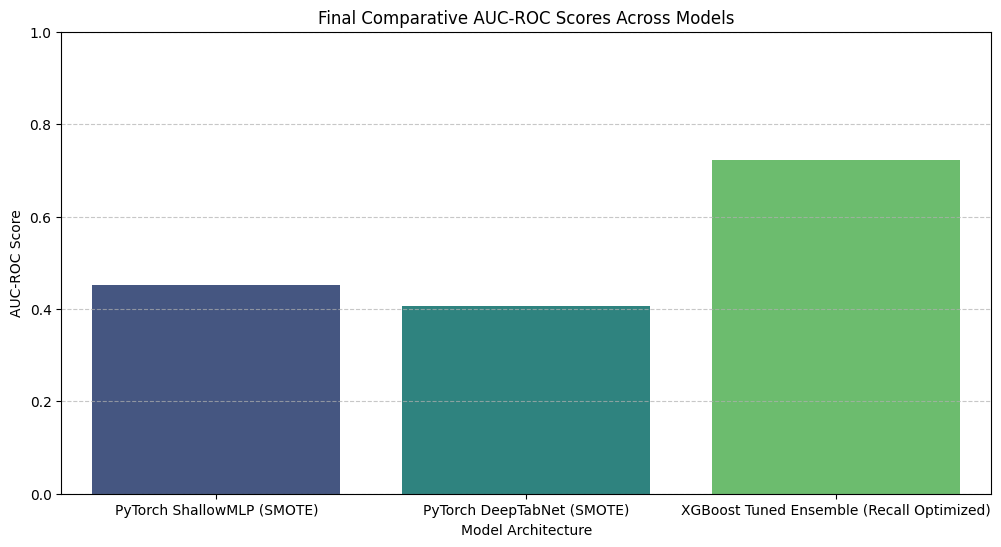

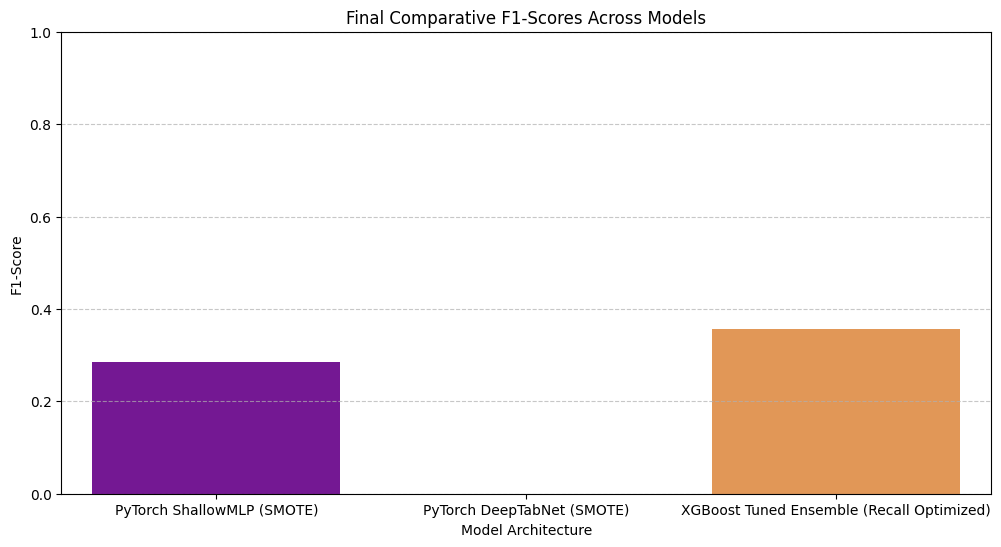

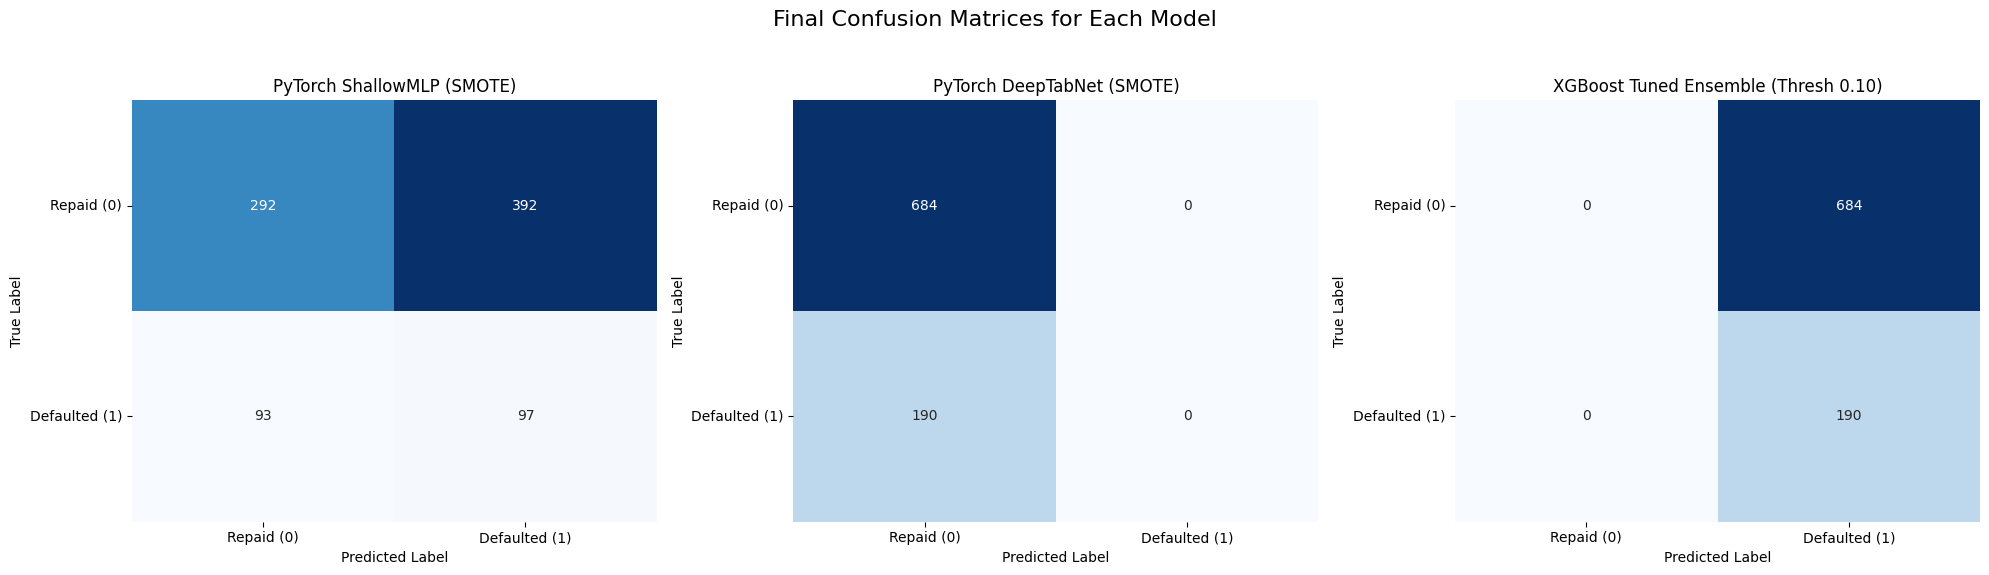

In [56]:
# Extract predictions from the retrained PyTorch models
shallow_probs_resampled = get_nn_probs(shallow_model_resampled)
deep_probs_resampled = get_nn_probs(deep_model_resampled)

shallow_preds_resampled = (shallow_probs_resampled > 0.5).astype(int)
deep_preds_resampled = (deep_probs_resampled > 0.5).astype(int)

# Compile metrics for all models, including the retrained PyTorch models and tuned XGBoost
metrics_shallow_resampled = evaluate_model_with_threshold(y_val, shallow_probs_resampled, 0.5, 'PyTorch ShallowMLP (SMOTE)')
metrics_deep_resampled = evaluate_model_with_threshold(y_val, deep_probs_resampled, 0.5, 'PyTorch DeepTabNet (SMOTE)')
metrics_xgb_tuned = evaluate_model_with_threshold(y_val, xgb_probs, xgb_optimal_threshold, 'XGBoost Tuned Ensemble (Recall Optimized)')

df_metrics_final = pd.DataFrame([
    metrics_shallow_resampled,
    metrics_deep_resampled,
    metrics_xgb_tuned
])

# --- Visual Implementation of Final Assessment Matrix --- #
print("\n--- Final Comparative Model Performance Metrics (SMOTE & Tuned XGBoost) ---")
print(df_metrics_final.round(3).to_markdown(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(x='Model Architecture', y='AUC-ROC', data=df_metrics_final, palette='viridis')
plt.title('Final Comparative AUC-ROC Scores Across Models')
plt.ylabel('AUC-ROC Score')
plt.xlabel('Model Architecture')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model Architecture', y='F1-Score', data=df_metrics_final, palette='plasma')
plt.title('Final Comparative F1-Scores Across Models')
plt.ylabel('F1-Score')
plt.xlabel('Model Architecture')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Visual Implementation of Truth Tables (Confusion Matrices) --- #
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Final Confusion Matrices for Each Model', fontsize=16)

plot_confusion_matrix(axes[0], y_val, shallow_preds_resampled, 'PyTorch ShallowMLP (SMOTE)')
plot_confusion_matrix(axes[1], y_val, deep_preds_resampled, 'PyTorch DeepTabNet (SMOTE)')
plot_confusion_matrix(axes[2], y_val, xgb_preds_tuned, f'XGBoost Tuned Ensemble (Thresh {xgb_optimal_threshold:.2f})')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [59]:
# Executing Disaggregated Algorithmic Fairness Evaluation
# Reconstruct the original categorical context for the validation set
val_indices = y_val.index
df_val_original = df_master.loc[val_indices]

# Re-calculate xgb_probs to ensure it reflects the latest tuned model and X_val
xgb_probs = best_xgb_model.predict_proba(X_val)[:, 1]

# Anchor the fairness evaluation to the best-performing model (XGBoost)
df_val_original['predicted_prob'] = xgb_probs

print("--- Responsible AI Audit: Disaggregated AUC-ROC by Employment Status ---")
disaggregated_results = []

for status in df_val_original['employment_status_clients'].dropna().unique():
    subset = df_val_original[df_val_original['employment_status_clients'] == status]
    subset_size = len(subset)

    # Mathematical requirement: AUC cannot be calculated if the subset contains only one class
    if len(subset['default_flag'].unique()) > 1:
        subset_auc = roc_auc_score(subset['default_flag'], subset['predicted_prob'])
        disaggregated_results.append({'Employment Status': status, 'Sample Size': subset_size, 'AUC-ROC': subset_auc})

df_fairness = pd.DataFrame(disaggregated_results).sort_values(by='AUC-ROC', ascending=False)

--- Responsible AI Audit: Disaggregated AUC-ROC by Employment Status ---


In [60]:
#  Artifact Serialization for Production Deployment
MODEL_DIR = '/content/drive/MyDrive/Ngao Labs/Ngao_Capstone_Project/Model'
os.makedirs(MODEL_DIR, exist_ok=True)

# Serialize the unified preprocessing pipeline
preprocessor_path = os.path.join(MODEL_DIR, 'loan_preprocessor.joblib')
joblib.dump(preprocessor, preprocessor_path, compress=True)
print(f"Data Preprocessor strictly serialized at: {preprocessor_path}")

# Serialize the PyTorch ShallowMLP weights (retrained model)
# Saving strictly the state_dict ensures modularity and prevents arbitrary code execution threats
pytorch_model_path = os.path.join(MODEL_DIR, 'shallow_mlp_state_dict.pth')
torch.save(shallow_model_resampled.state_dict(), pytorch_model_path)
print(f"PyTorch ShallowMLP weights safely extracted to: {pytorch_model_path}")

# Serialize the XGBoost Tuned Baseline Model
xgb_model_path = os.path.join(MODEL_DIR, 'xgb_tuned_baseline.json')
best_xgb_model.save_model(xgb_model_path)
print(f"XGBoost production trees compiled to: {xgb_model_path}")

Data Preprocessor strictly serialized at: /content/drive/MyDrive/Ngao Labs/Ngao_Capstone_Project/Model/loan_preprocessor.joblib
PyTorch ShallowMLP weights safely extracted to: /content/drive/MyDrive/Ngao Labs/Ngao_Capstone_Project/Model/shallow_mlp_state_dict.pth
XGBoost production trees compiled to: /content/drive/MyDrive/Ngao Labs/Ngao_Capstone_Project/Model/xgb_tuned_baseline.json


In [61]:
#  Defining the Production Inference Service
class LoanDefaultInferenceService:
    def __init__(self, preprocessor_path, mlp_path, xgb_path, input_dim):
        # Instantiate objects from serialized disk storage
        self.preprocessor = joblib.load(preprocessor_path)

        # Load XGBoost directly
        self.xgb_model = xgb.XGBClassifier()
        self.xgb_model.load_model(xgb_path)

        # Re-initialize the PyTorch Network Topology and bind weights
        self.mlp_model = ShallowMLP(input_dim)
        # Parameter map_location=torch.device('cpu') guarantees execution on web servers without GPUs
        self.mlp_model.load_state_dict(
            torch.load(mlp_path, map_location=torch.device('cpu'), weights_only=True)
        )
        self.mlp_model.eval() # Lock network for inference

    def predict(self, raw_applicant_df):
        """
        Receives raw applicant data (as a Pandas DataFrame), scales it,
        and routes it through both models for ensemble scoring.
        """
        # Pass through the exact scaling/encoding geometry
        X_processed = self.preprocessor.transform(raw_applicant_df)

        #  XGBoost Probabilistic Inference
        xgb_prob = self.xgb_model.predict_proba(X_processed)[:, 1]

        #  PyTorch Probabilistic Inference
        with torch.no_grad():
            X_tensor = torch.tensor(X_processed, dtype=torch.float32)
            logits = self.mlp_model(X_tensor)
            mlp_prob = torch.sigmoid(logits).numpy().flatten()

        return {
            'XGBoost_Default_Probability': xgb_prob,
            'PyTorch_Default_Probability': mlp_prob,
            'Ensemble_Risk_Score': (xgb_prob * 0.6) + (mlp_prob * 0.4) # Weighted preference to XGBoost
        }

# Simulate a new, incoming web-request representing a rural applicant
sample_applicant = X.iloc[[0]] # Fixed: Select the first row as a DataFrame
print("\n--- Simulating Live API Inference Request ---")
inference_api = LoanDefaultInferenceService(
    preprocessor_path, pytorch_model_path, xgb_model_path, input_dimension
)

risk_profile = inference_api.predict(sample_applicant)
print("Inference Payload Response:")
for key, val in risk_profile.items():
    # Access the scalar value from the numpy array before formatting
    print(f" - {key}: {val[0]:.4f}")

# Accessing the ensemble risk score correctly from the dictionary
if risk_profile['Ensemble_Risk_Score'] > 0.5:
    print("\nSYSTEM ACTION: FLAG HIGH RISK (Initiate Manual Underwriter Review)")
else:
    print("\nSYSTEM ACTION: FLAG LOW RISK (Approve Micro-Loan Disbursement)")


--- Simulating Live API Inference Request ---
Inference Payload Response:
 - XGBoost_Default_Probability: 0.4489
 - PyTorch_Default_Probability: 0.2753
 - Ensemble_Risk_Score: 0.3795

SYSTEM ACTION: FLAG LOW RISK (Approve Micro-Loan Disbursement)
